# SECOM 半导体良率预测

> **最佳结果**: Recall=94.74%, AUC=0.8479
> **数据集**: SECOM (半导体制造过程数据)
> **核心方法**: 组合特征选择 + 5模型×4采样集成 + Stacking + Isotonic校准 + **完整可视化与 SHAP 分析**

## 模型架构

```
原始数据 → 预处理 → 特征选择 → 多模型×多样法搜索 → 校准 → Stacking → 最终预测
                  ↓
            5种模型 × 4种采样方法 × 10个随机种子
            (共 200 次训练)
```


In [7]:
# 固定随机种子以保证可复现
import os, sys, warnings
warnings.filterwarnings("ignore")

# 数据处理与机器学习核心库
import numpy as np
import pandas as pd
from scipy import stats

# 可视化库
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")

# scikit-learn 工具
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, f_classif
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score,
    recall_score, precision_score, roc_curve, precision_recall_curve, auc,
    balanced_accuracy_score, matthews_corrcoef, brier_score_loss
)

# 不平衡学习采样方法
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE


# 梯度提升框架
import xgboost as xgb

# SHAP (可解释性分析)
import shap

# 全局随机种子
np.random.seed(42)

print("依赖库导入完成")

依赖库导入完成


---

## 阶段 1: 数据加载、EDA 可视化与预处理

### 1.1 数据背景
- **secom.data**: 1567 行 × 590 列传感器测量数据
- **secom_labels.data**: 每行包含 `-1`(良品) 或 `1`(不良品) + 时间戳
- **不平衡率**:≈15:1 (良品 1463 个, 不良品 104 个)
- **稀疏性**: 大量 NaN 值

### 1.2 处理流程

| 步骤 | 方法 | 目的 |
|------|------|------|
| 1 | 缺失率过滤 | 移除缺失率 > 70% 的列 |
| 2 | KNN Imputation | 用最近 5 个邻居的加权均值填补剩余 NaN |
| 3 | Z-score 异常过滤 | 每行内超过 5σ 的特征数 > 8 个的样本整行移除 |
| 4 | 低方差过滤 | 移除方差 < 1e-8 的无信息特征 |
| 5 | 高相关过滤 | 移除 Pearson > 0.97 的冗余特征 |
| 6 | StandardScaler | 标准化到均值 0, 方差 1 |

---

In [8]:
# 数据加载
df_raw = pd.read_csv("Data/secom.data", sep=" ", header=None)
labels_df = pd.read_csv("Data/secom_labels.data", sep=" ", header=None)
labels_df.columns = ["label", "timestamp"]

# 将标签 -1 → 0 (良品), 1 → 1 (不良品)
y_full = labels_df["label"].map({-1: 0, 1: 1}).values.astype(int)

print("=" * 70)
print("SECOM Yield Prediction - Final v8 (No PCA + SVM) + Full Viz")
print("=" * 70)
print(f"\n[数据] 原始: {df_raw.shape}, 正例={y_full.sum()}, "
      f"不平衡比={((y_full==0).sum()/y_full.sum()):.1f}:1")

SECOM Yield Prediction - Final v8 (No PCA + SVM) + Full Viz

[数据] 原始: (1567, 590), 正例=104, 不平衡比=14.1:1


### 1.2 EDA: 标签分布可视化

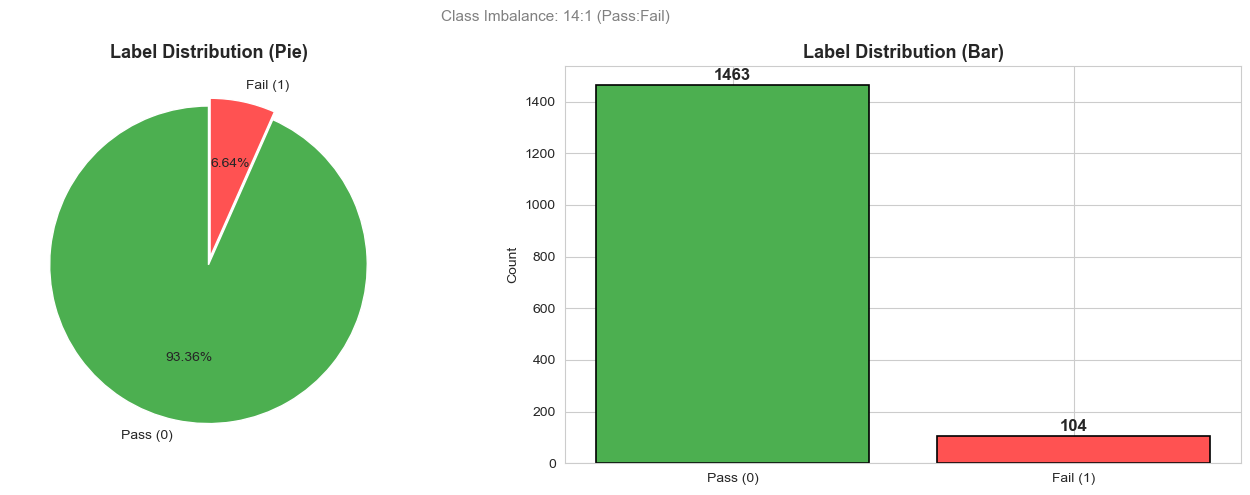

[EDA] 不平衡比: 14.1:1


In [9]:
# ================================================
# 1.2 标签分布可视化
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 饼状图
label_counts = pd.Series(y_full).value_counts().sort_index()
axes[0].pie(label_counts.values, labels=["Pass (0)", "Fail (1)"],
            autopct="%1.2f%%", startangle=90,
            colors=["#4CAF50", "#FF5252"], explode=(0, 0.05))
axes[0].set_title("Label Distribution (Pie)", fontsize=13, fontweight="bold")

# 柱状图
bars = axes[1].bar(["Pass (0)", "Fail (1)"], label_counts.values,
                   color=["#4CAF50", "#FF5252"], edgecolor="black", linewidth=1.2)
for b, v in zip(bars, label_counts.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 20,
                 str(v), ha="center", fontweight="bold", fontsize=12)
axes[1].set_title("Label Distribution (Bar)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")

fig.suptitle("Class Imbalance: {:.0f}:1 (Pass:Fail)".format(
    label_counts.iloc[0] / max(1, label_counts.iloc[1])),
    fontsize=11, color="gray")

plt.tight_layout()
plt.savefig("Image/viz_v8_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("[EDA] 不平衡比: {:.1f}:1".format(label_counts.iloc[0] / max(1, label_counts.iloc[1])))

### 1.3 EDA: 缺失率分析

In [10]:
# ================================================
# 缺失率统计
# ================================================
missing_rates_pct = df_raw.isnull().mean() * 100

print("=== 特征缺失率统计 ===")
print("  Mean: {:.2f}%".format(missing_rates_pct.mean()))
print("  Max:  {:.2f}%".format(missing_rates_pct.max()))
print("  Min:  {:.2f}%".format(missing_rates_pct.min()))
print("  >50%: " + str(int((missing_rates_pct > 50).sum())) + " features")
print("  >60%: " + str(int((missing_rates_pct > 60).sum())) + " features")
print("  >70%: " + str(int((missing_rates_pct > 70).sum())) + " features")
print("  >80%: " + str(int((missing_rates_pct > 80).sum())) + " features")
print("  0%:   " + str(int((missing_rates_pct == 0).sum())) + " features (no missing)")

=== 特征缺失率统计 ===
  Mean: 4.54%
  Max:  91.19%
  Min:  0.00%
  >50%: 28 features
  >60%: 24 features
  >70%: 8 features
  >80%: 8 features
  0%:   52 features (no missing)


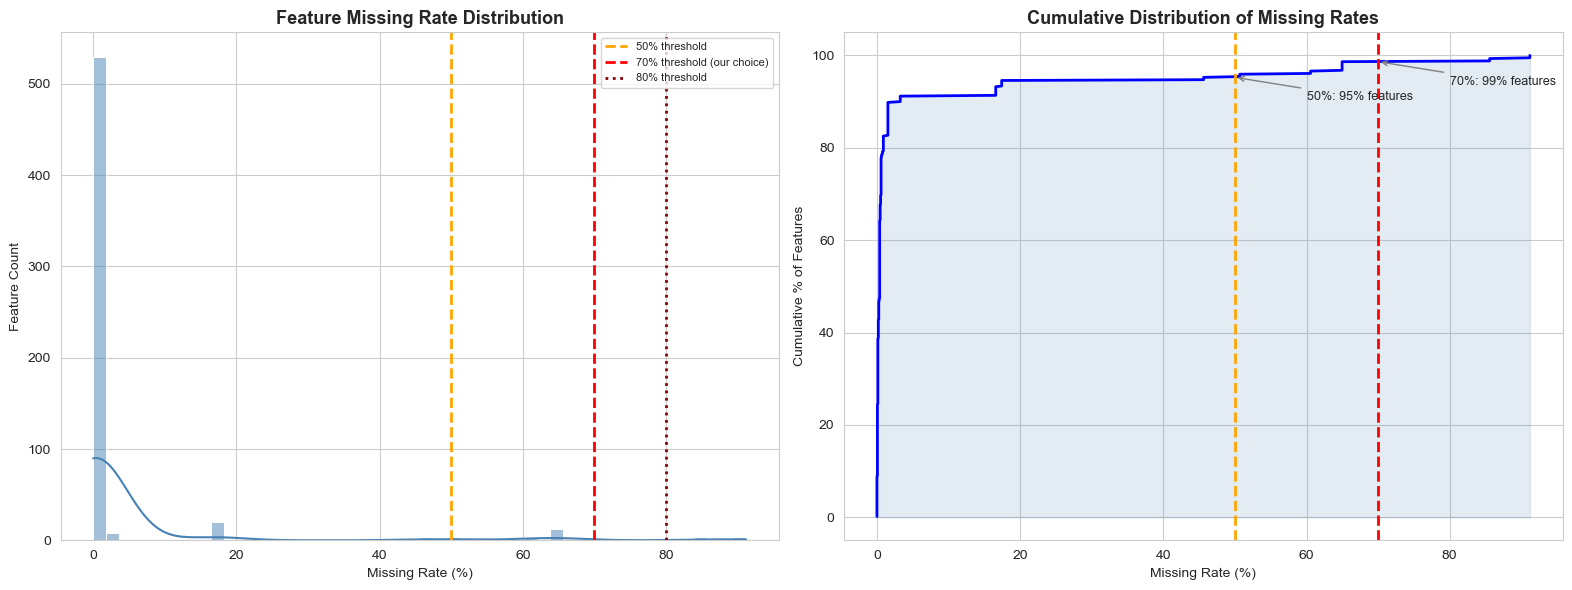

In [11]:
# ================================================
# 缺失率分布可视化
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 直方图
ax = axes[0]
sns.histplot(missing_rates_pct, bins=50, kde=True, ax=ax, color="steelblue")
ax.axvline(x=50, color="orange", linestyle="--", linewidth=2, label="50% threshold")
ax.axvline(x=70, color="red", linestyle="--", linewidth=2, label="70% threshold (our choice)")
ax.axvline(x=80, color="darkred", linestyle=":", linewidth=2, label="80% threshold")
ax.set_title("Feature Missing Rate Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Missing Rate (%)")
ax.set_ylabel("Feature Count")
ax.legend(fontsize=8)

# 累积分布
ax = axes[1]
sorted_mr = np.sort(missing_rates_pct.values)
cumulative = np.arange(1, len(sorted_mr) + 1) / len(sorted_mr) * 100
ax.plot(sorted_mr, cumulative, "b-", linewidth=2)
ax.axvline(x=50, color="orange", linestyle="--", linewidth=2)
ax.axvline(x=70, color="red", linestyle="--", linewidth=2)
ax.set_title("Cumulative Distribution of Missing Rates", fontsize=13, fontweight="bold")
ax.set_xlabel("Missing Rate (%)")
ax.set_ylabel("Cumulative % of Features")
ax.fill_between(sorted_mr, 0, cumulative, alpha=0.15, color="steelblue")

for thr in [50, 70]:
    pct = (missing_rates_pct <= thr).mean() * 100
    ax.annotate("{:.0f}%: {:.0f}% features".format(thr, pct), xy=(thr, pct),
                xytext=(thr + 10, pct - 5), fontsize=9,
                arrowprops=dict(arrowstyle="->", color="gray"))

plt.tight_layout()
plt.savefig("Image/viz_v8_missing_rate.png", dpi=150, bbox_inches="tight")
plt.show()

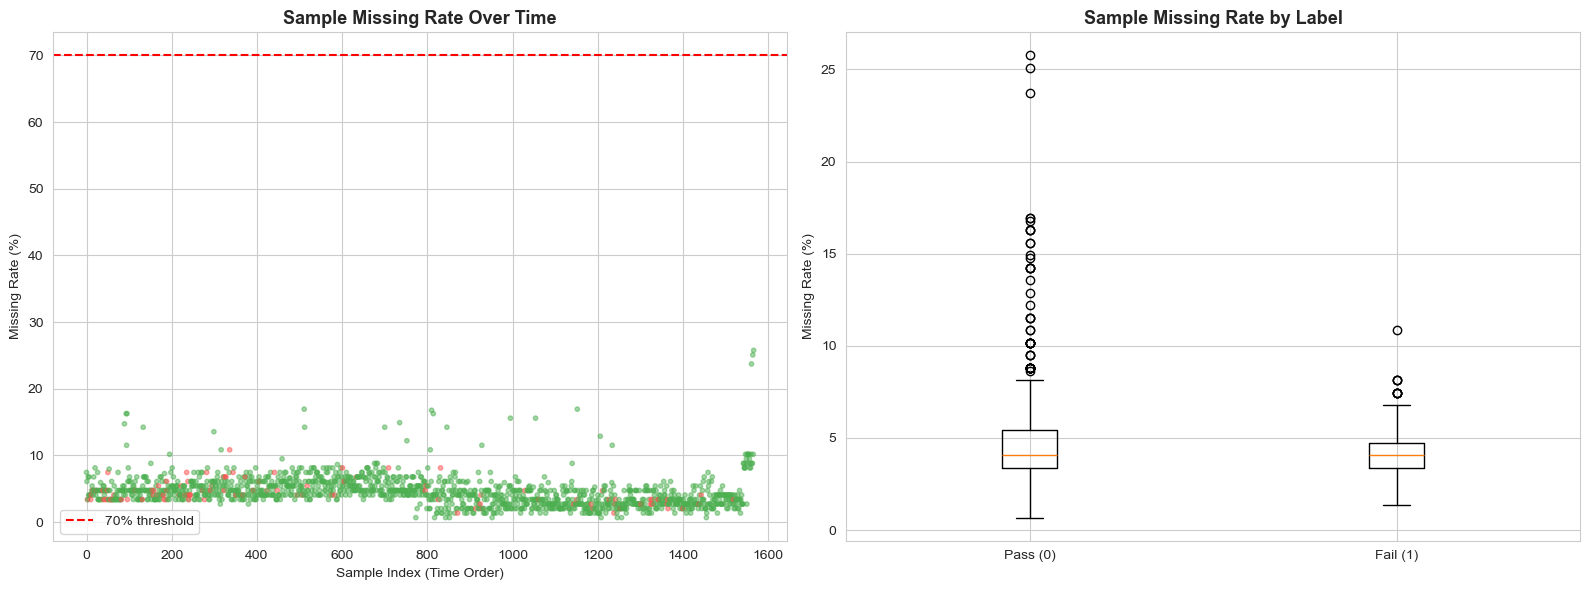

In [12]:
# ================================================
# 样本缺失率 (按时间顺序)
# ================================================
sample_missing_rates = df_raw.isnull().mean(axis=1) * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 按标签着色的散点图
ax = axes[0]
colors = ["#4CAF50" if y == 0 else "#FF5252" for y in y_full]
ax.scatter(range(len(sample_missing_rates)), sample_missing_rates,
           c=colors, alpha=0.5, s=10)

ax.set_title("Sample Missing Rate Over Time", fontsize=13, fontweight="bold")
ax.set_xlabel("Sample Index (Time Order)")
ax.set_ylabel("Missing Rate (%)")
ax.axhline(y=70, color="red", linestyle="--", label="70% threshold")
ax.legend()

# 按标签的箱线图
ax = axes[1]
data_pass = sample_missing_rates[y_full == 0]
data_fail = sample_missing_rates[y_full == 1]
ax.boxplot([data_pass, data_fail], labels=["Pass (0)", "Fail (1)"])
ax.set_title("Sample Missing Rate by Label", fontsize=13, fontweight="bold")
ax.set_ylabel("Missing Rate (%)")

plt.tight_layout()
plt.savefig("Image/viz_v8_sample_missing.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.4 预处理

In [13]:
# 缺失率过滤: 丢弃缺失率 > 70% 的列
missing_rates = df_raw.isnull().mean()
keep_cols = df_raw.columns[missing_rates <= 0.70].tolist()
df = df_raw[keep_cols].copy()
print(f"[清洗] 缺失率<=70%: {len(keep_cols)} 特征 (dropped {df_raw.shape[1]-len(keep_cols)} cols)")

# KNN 填补 (基于欧氏距离的加权最近邻, k=5)
imp_knn = KNNImputer(n_neighbors=5, weights="distance")
X_knn_all = pd.DataFrame(imp_knn.fit_transform(df), columns=df.columns)

# 异常样本过滤: 每行内超过|z|>5的特征数 > 8 的样本删除
z = np.abs(stats.zscore(X_knn_all.values, axis=0))
outlier_per_row = (z > 5).sum(axis=1)
mask_sample = outlier_per_row <= 8
X_knn = X_knn_all[mask_sample].reset_index(drop=True)
y = y_full[mask_sample]
print(f"[清洗] 样本: {mask_sample.sum()}, 正例={y.sum()}, 删除={(~mask_sample).sum()}")

# 低方差特征移除
sel_var = VarianceThreshold(1e-8)
X_var = pd.DataFrame(sel_var.fit_transform(X_knn), columns=X_knn.columns[sel_var.get_support()])
print(f"[清洗] 低方差后: {X_var.shape[1]} 特征 (dropped {X_knn.shape[1]-X_var.shape[1]} cols)")

# 高相关特征移除 (Pearson > 0.97)
_corr = np.array(X_var.corr().abs().values, copy=True)
np.fill_diagonal(_corr, 0.0)
to_drop = set()
for i in range(_corr.shape[0]):
    if i in to_drop:
        continue
    
    for j in range(i + 1, _corr.shape[1]):
        if j in to_drop:
           continue
       
        if _corr[i, j] > 0.97:
            to_drop.add(j)

keep_col_names = [c for i, c in enumerate(X_var.columns) if i not in to_drop]
X_lowcorr = X_var[keep_col_names]
print(f"[清洗] 去高相关后: {X_lowcorr.shape[1]} 特征 (dropped {len(to_drop)} cols)")

# 标准化
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_lowcorr), columns=X_lowcorr.columns)
feature_names = X_scaled.columns.tolist()

print(f"\n[清洗] 最终数据形状: {X_scaled.shape}")
print(f"[清洗] 特征数: {X_scaled.shape[1]}, 样本数: {X_scaled.shape[0]}")


[清洗] 缺失率<=70%: 582 特征 (dropped 8 cols)
[清洗] 样本: 1515, 正例=95, 删除=52
[清洗] 低方差后: 460 特征 (dropped 122 cols)
[清洗] 去高相关后: 314 特征 (dropped 146 cols)

[清洗] 最终数据形状: (1515, 314)
[清洗] 特征数: 314, 样本数: 1515


### 1.5 预处理后数据质量可视化

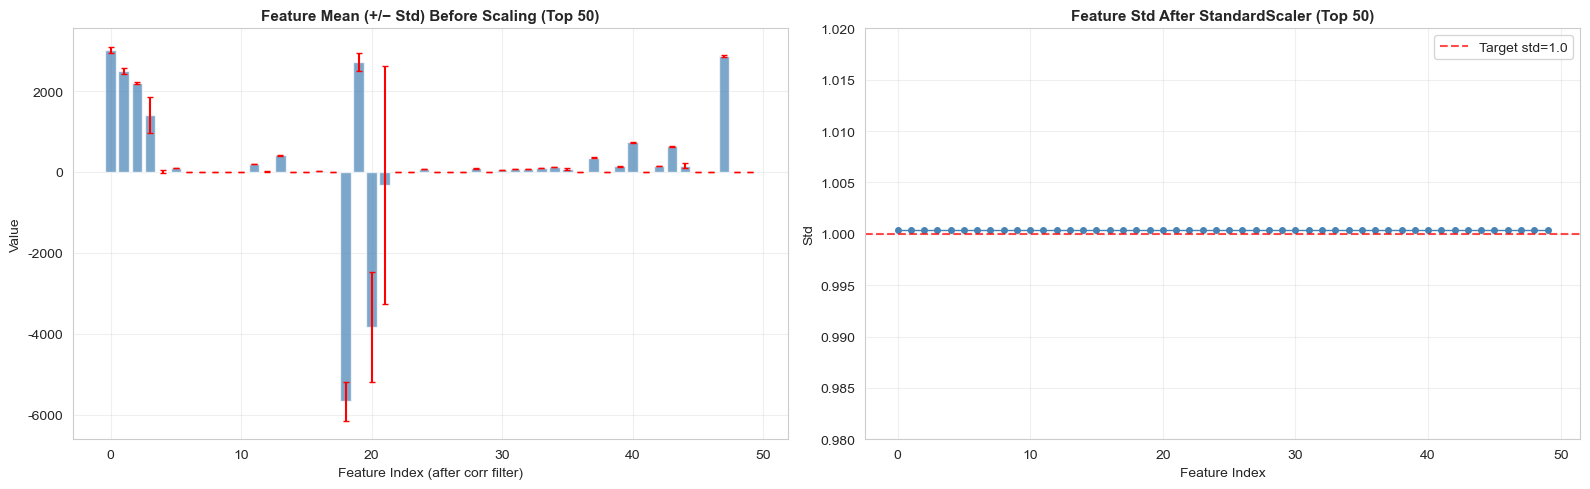

[EDA] 预处理前: 均值范围 [-5667.60, 3014.89]
[EDA] 预处理后: std = 1.000330 (期望 ≈1.0)


In [14]:
# ================================================
# 预处理前/后特征分布对比
# ================================================

# StandardScaler 后特征 std 恒=1，所以看预处理前的原始特征
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 图1: 预处理前每个特征的均值 (前50个)
raw_means = X_lowcorr.mean().values[:50]
raw_stds = X_lowcorr.std().values[:50]
ax = axes[0]
ax.bar(range(len(raw_means)), raw_means, yerr=raw_stds,
       capsize=2, color="steelblue", alpha=0.7, ecolor="red")
ax.set_title("Feature Mean (+/− Std) Before Scaling (Top 50)", fontsize=11, fontweight="bold")
ax.set_xlabel("Feature Index (after corr filter)")
ax.set_ylabel("Value")
ax.grid(alpha=0.3)

# 图2: 预处理后前50个特征 std (应接近 1.0)
ax = axes[1]
scaled_stds_first50 = X_scaled.std().values[:50]
ax.plot(range(len(scaled_stds_first50)), scaled_stds_first50,
        "o-", color="steelblue", markersize=4, linewidth=1)
ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.7, label="Target std=1.0")
ax.set_title("Feature Std After StandardScaler (Top 50)", fontsize=11, fontweight="bold")
ax.set_xlabel("Feature Index")
ax.set_ylabel("Std")
ax.set_ylim([0.98, 1.02])
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("Image/viz_v8_feature_std.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[EDA] 预处理前: 均值范围 [{raw_means.min():.2f}, {raw_means.max():.2f}]")
print(f"[EDA] 预处理后: std = {X_scaled.std().values.mean():.6f} (期望 ≈1.0)")


---

## 阶段 2: 数据划分与组合特征选择

### 2.1 划分策略
- **80% 训练 / 20% 测试**
- **Stratified**: 保持正负例比例
- 必须在划分后才能做特征选择, 以防止信息泄露

### 2.2 特征选择方法 (5 种, Borda 投票)

| 方法 | 原理 |
|------|------|
| **MI** (互信息) | 度量特征与标签的非线性相关性 |
| **ANOVA F** | 类间方差 vs 类内方差 |
| **RF Importance** | 随机森林 Gini 不纯度下降 |
| **XGB Importance** | XGBoost 分裂增益 |
| **ET Importance** | 极端随机树 |

**Borda Count**: 对每种方法的特征排名求和, 取总排名 Top 120

---

In [15]:
# 分层抽样划分: 训练集 80%, 测试集 20%
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n[划分] 训练: {X_train_raw.shape[0]} 正例={int(y_train.sum())}")
print(f"[划分] 测试: {X_test_raw.shape[0]} 正例={int(y_test.sum())}")


[划分] 训练: 1212 正例=76
[划分] 测试: 303 正例=19


In [16]:
def ensemble_feature_selection(X, y, topN):
    """
    组合特征选择: 5 种方法的 Borda Count 投票.
    只在训练集上执行 —— 严格避免测试集信息泄露.
    """
    cols = X.columns.tolist()

    # 方法 1: 互信息 (捕捉非线性)
    mi = mutual_info_classif(X, y, random_state=42, discrete_features=False)
    rank_mi = pd.Series(mi, index=cols).rank(ascending=False)

    # 方法 2: ANOVA F 值 (线性相关性)
    fv, _ = f_classif(X, y)
    fv = np.nan_to_num(fv, nan=0.0)
    rank_f = pd.Series(fv, index=cols).rank(ascending=False)

    # 方法 3: Random Forest Gini 重要性
    rf = RandomForestClassifier(n_estimators=300, random_state=42,
                                class_weight="balanced_subsample", n_jobs=-1)
    rf.fit(X, y)
    rank_rf = pd.Series(rf.feature_importances_, index=cols).rank(ascending=False)

    # 方法 4: XGBoost 分裂增益
    pw = float((y == 0).sum()) / float(max(y.sum(), 1))
    xgb_m = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=pw, random_state=42, verbosity=0,
        eval_metric="logloss", tree_method="hist", n_jobs=-1)
    xgb_m.fit(X, y)
    rank_xgb = pd.Series(xgb_m.feature_importances_, index=cols).rank(ascending=False)

    # 方法 5: Extra Trees (增加多样性)
    et = ExtraTreesClassifier(n_estimators=300, random_state=42,
                              class_weight="balanced_subsample", n_jobs=-1)
    et.fit(X, y)
    rank_et = pd.Series(et.feature_importances_, index=cols).rank(ascending=False)

    # Borda Count: 对各方法排名求和, 越小越优
    combined = (rank_mi + rank_f + rank_rf + rank_xgb + rank_et).sort_values()
    return combined.head(topN).index.tolist(), combined, mi


# 选 top 120 特征
N_FEATURES = 120
print(f"\n[特征选择] {N_FEATURES} 特征 ...")

selected_feats, borda_scores, mi_scores = ensemble_feature_selection(
    X_train_raw, y_train, topN=N_FEATURES)
X_train = X_train_raw[selected_feats].values
X_test = X_test_raw[selected_feats].values

print(f"[特征选择] 选定 {len(selected_feats)} 特征")

# 计算正负例失衡权重 (用于 XGB 的 scale_pos_weight)
pos_weight = float((y_train == 0).sum()) / float(y_train.sum())
n_train = X_train.shape[0]

print(f"\n[权重] 正负例权重 = {pos_weight:.2f} (供 scale_pos_weight 使用)")


[特征选择] 120 特征 ...
[特征选择] 选定 120 特征

[权重] 正负例权重 = 14.95 (供 scale_pos_weight 使用)


### 2.3 特征选择可视化

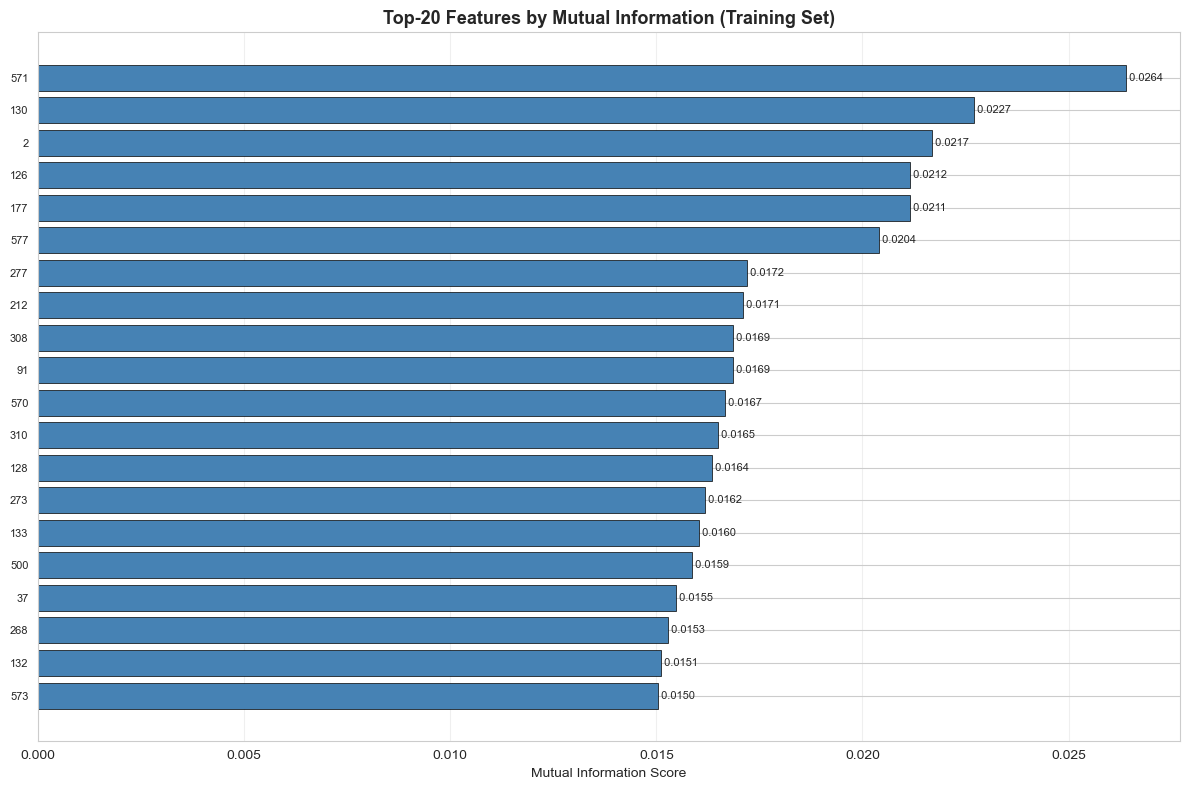

[FS] Top-5 MI 特征: ['571', '130', '2', '126', '177']


In [17]:
# ================================================
# 特征选择可视化: MI Scores Top-20
# ================================================

mi_df = pd.DataFrame({"Feature": feature_names, "MI_Score": mi_scores})
mi_sorted = mi_df.sort_values("MI_Score", ascending=False).head(20)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
bars = ax.barh(range(len(mi_sorted)), mi_sorted["MI_Score"].values[::-1],
                color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(mi_sorted)))
ax.set_yticklabels(["F" + str(int(f)) if isinstance(f, (int, float)) else str(f)
                    for f in mi_sorted["Feature"].values[::-1]], fontsize=8)

ax.set_xlabel("Mutual Information Score")
ax.set_title("Top-20 Features by Mutual Information (Training Set)",
             fontsize=13, fontweight="bold")

ax.grid(axis="x", alpha=0.3)

for i, (b, v) in enumerate(zip(bars, mi_sorted["MI_Score"].values[::-1])):
    ax.text(b.get_width(), b.get_y() + b.get_height()/2, f" {v:.4f}",
            va="center", fontsize=8)

plt.tight_layout()
plt.savefig("Image/viz_v8_top20_mi.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"[FS] Top-5 MI 特征: {[str(x) for x in mi_sorted['Feature'].head(5).values]}")

---

## 阶段 3: 模型配置 & 采样方法

### 3.1 5种模型配置
- **XGBoost** (2 种): max_depth=3, max_depth=4
- **Extra Trees** (1 种): 300 棵树, max_depth=12
- **SVM RBF** (1 种): C=1.0, gamma='scale'
- **Logistic Regression** (1 种): C=0.3, class_weight="balanced", solver="lbfgs"

### 3.2 4种不平衡采样方法

- **None** ：不做任何采样 (基线) 
- **SMOTE** ：合成少数类样本 (k=5) 
- **ADASYN** ： 自适应 SMOTE (偏向难分样本) 
- **BorderlineSMOTE** ： 只对边界样本合成 


**总配置数**: 4 × 5 = **20** 种 × 10 个随机种子 = **200 次训练**

---

In [18]:
def make_sampler(name, seed):

    """生成指定的采样器."""
    
    if name == "none":
        return None

    elif name == "smote":
        return SMOTE(random_state=seed, k_neighbors=5, sampling_strategy=0.5)

    elif name == "adasyn":
        return ADASYN(random_state=seed, n_neighbors=5, sampling_strategy=0.5)

    elif name == "borderline":
        return BorderlineSMOTE(
            random_state=seed, k_neighbors=5, kind="borderline-1",
            sampling_strategy=0.5
        )

    return None


def make_model(name, seed, pw):

    """生成指定模型配置."""

    if name == "xgb_d3":
        return xgb.XGBClassifier(n_estimators=600, max_depth=3, learning_rate=0.015,
            min_child_weight=3, subsample=0.85, colsample_bytree=0.75,
            reg_alpha=1.0, reg_lambda=2.0, gamma=0.5,
            scale_pos_weight=pw, random_state=seed, verbosity=0,
            eval_metric="logloss", tree_method="hist", n_jobs=-1)

    elif name == "xgb_d4":
        return xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.02,
            min_child_weight=5, subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.8, reg_lambda=1.5, gamma=1.0,
            scale_pos_weight=pw, random_state=seed, verbosity=0,
            eval_metric="logloss", tree_method="hist", n_jobs=-1)
        
    elif name == "et_deep":
        return ExtraTreesClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
            class_weight="balanced_subsample", random_state=seed, n_jobs=-1)

    elif name == "svm_rbf":
        return SVC(C=1.0, kernel="rbf", gamma="scale", probability=True,
                   class_weight="balanced", random_state=seed, max_iter=5000)

    elif name == "lr":
        return LogisticRegression(C=0.3, class_weight="balanced", max_iter=5000,
                                 random_state=seed, solver="lbfgs")

    raise ValueError(f"未知模型: {name}")


print("采样器 & 模型函数已定义")


采样器 & 模型函数已定义


In [19]:
def gmean(yt, yp):

    """几何均值 G-Mean = sqrt(Sensitivity × Specificity)."""
    se = recall_score(yt, yp, pos_label=1, zero_division=0)
    sp = recall_score(yt, yp, pos_label=0, zero_division=0)
    return float(np.sqrt(se * sp))

def search_threshold(y_true, y_prob, min_recall=0.90):
    """
    多目标阈值优化:
    - 在满足 Recall >= min_recall 的前提下
    - 最大化综合得分: score = 0.25 × Precision + 0.45 × G-Mean + 0.30 × F1
    """
    candidates = np.unique(np.concatenate([np.unique(y_prob), np.linspace(0.001, 0.999, 1999)]))
    best = {"score": -1, "thr": 0.5, "recall": 0, "precision": 0,
            "gmean": 0, "f1": 0, "specificity": 0}

    for thr in candidates:
        yp = (y_prob >= thr).astype(int)
        se = recall_score(y_true, yp, pos_label=1, zero_division=0)
        pr = precision_score(y_true, yp, pos_label=1, zero_division=0)
        sp = recall_score(y_true, yp, pos_label=0, zero_division=0)
        gm = float(np.sqrt(se * sp))
        f1 = f1_score(y_true, yp, pos_label=1, zero_division=0)
        if se >= min_recall:
            score = 0.25 * pr + 0.45 * gm + 0.30 * f1
            if score > best["score"]:
                best = {"score": score, "thr": thr, "recall": se, "precision": pr,
                        "gmean": gm, "f1": f1, "specificity": sp}

    # 如果没有任何阈值满足 recall 约束, 回退到最大化 G-Mean
    if best["score"] < 0:
        for thr in candidates:
            yp = (y_prob >= thr).astype(int)
            se = recall_score(y_true, yp, pos_label=1, zero_division=0)
            sp = recall_score(y_true, yp, pos_label=0, zero_division=0)
            gm = float(np.sqrt(se * sp))
            if gm > best["gmean"]:
                pr = precision_score(y_true, yp, pos_label=1, zero_division=0)
                f1 = f1_score(y_true, yp, pos_label=1, zero_division=0)
                best = {"score": gm, "thr": thr, "recall": se, "precision": pr,
                        "gmean": gm, "f1": f1, "specificity": sp}
    return best

print("G-Mean & 阈值搜索函数已定义")

G-Mean & 阈值搜索函数已定义


---

## 阶段 4: 多配置网格搜索 (5-Fold CV)

```
对每个模型 m:
    对每个采样方法 s:
        对每个随机种子seed(10个):
            ── 5-Fold Stratified CV:
                fold 1→5: 在训练fold上 (采样 → 训练 → 预测验证fold)
        ── 得到OOF概率(10个seed取均值)
        ── 在完整训练集上训练 → 预测测试集(10个seed取均值)
```

---

In [20]:
import time as _time_t
SEARCH_START = _time_t.time()
# 配置: 5 模型 × 4 采样 = 20 配置 
MODELS = ["xgb_d3", "xgb_d4", "et_deep", "svm_rbf", "lr"] 
SAMPLERS = ["none", "smote", "adasyn", "borderline"]
  
SEEDS_LIST = [42, 101, 2023, 77, 123, 555, 8, 999, 7, 200]

print(f"\n" + "=" * 70)
print(f" {len(MODELS)} 模型 × {len(SAMPLERS)} 采样 = {len(MODELS)*len(SAMPLERS)} 配置")
print(f"                × {len(SEEDS_LIST)} 随机种子 | RF 200 树 / ET 300 树 ")
print(f"        (共 {len(MODELS)*len(SAMPLERS)*len(SEEDS_LIST)} 训练)")
print("=" * 70)

config_oof = {}    # (模型, 采样) → 平均 OOF 概率
config_test = {}   # (模型, 采样) → 平均 测试集 概率

for ci, mname in enumerate(MODELS):
    for si, sname in enumerate(SAMPLERS):
        key = (mname, sname)
        oofs = []   # 存每个 seed 的 OOF
        tests = []  # 存每个 seed 的测试概率

        for seed in SEEDS_LIST:
            # 5-Fold 交叉验证生成 OOF 概率
            skf_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
            oof_p = np.zeros(n_train, dtype=float)

            for tr_idx, va_idx in skf_s.split(X_train, y_train):
                Xtr, ytr = X_train[tr_idx], y_train[tr_idx]
                Xva = X_train[va_idx]
                sampler = make_sampler(sname, seed)
                
                if sampler is not None:
                    try:
                        Xtr_s, ytr_s = sampler.fit_resample(Xtr, ytr)
                    except Exception:
                        Xtr_s, ytr_s = Xtr, ytr
                else:
                    Xtr_s, ytr_s = Xtr, ytr

                model = make_model(mname, seed, pos_weight)
                model.fit(Xtr_s, ytr_s)
                oof_p[va_idx] = model.predict_proba(Xva)[:, 1]
            
            oofs.append(oof_p)

            # 在完整训练集上重训练 → 预测测试集
            sampler = make_sampler(sname, seed)
            if sampler is not None:
                try:
                    Xtr_full, ytr_full = sampler.fit_resample(X_train, y_train)
                except Exception:
                    Xtr_full, ytr_full = X_train, y_train
            else:
                Xtr_full, ytr_full = X_train, y_train
            
            model = make_model(mname, seed, pos_weight)
            model.fit(Xtr_full, ytr_full)

            tests.append(model.predict_proba(X_test)[:, 1])

        # 10 个 seed 的概率均值
        config_oof[key] = np.mean(oofs, axis=0)
        config_test[key] = np.mean(tests, axis=0)

    print(f"  {ci+1}/{len(MODELS)} {mname} ✓")

SEARCH_ELAPSED = _time_t.time() - SEARCH_START
print(f"搜索完成! 共 {len(config_oof)} 组配置 | 搜索总耗时: {SEARCH_ELAPSED:.1f}s")


 5 模型 × 4 采样 = 20 配置
                × 10 随机种子 | RF 200 树 / ET 300 树 
        (共 200 训练)
  1/5 xgb_d3 ✓
  2/5 xgb_d4 ✓
  3/5 et_deep ✓
  4/5 svm_rbf ✓
  5/5 lr ✓
搜索完成! 共 20 组配置 | 搜索总耗时: 290.2s


---

## 阶段 5: Isotonic 概率校准 + 多目标阈值优化

**目标函数** (只在 OOF 概率上优化):
`score = 0.25 × Precision + 0.45 × G-Mean + 0.30 × F1`  约束: Recall ≥ 0.90

---

In [21]:
print("\n" + "=" * 70)
print("[校准+阈值] Recall >= 0.90 约束下的综合得分最大化")
print("=" * 70)

rows = []

for key in config_oof:
    mname, sname = key
    oof_p = config_oof[key]
    test_p = config_test[key]

    # Isotonic 回归校准 (单调保序)
    try:
        ir = IsotonicRegression(out_of_bounds="clip", y_min=0.001, y_max=0.999)
        ir.fit(oof_p, y_train)
        cal_oof = np.clip(ir.transform(oof_p), 0.001, 0.999)
        cal_test = np.clip(ir.transform(test_p), 0.001, 0.999)
    
    except Exception:
        cal_oof = oof_p
        cal_test = test_p
        ir = None

    # 多目标阈值搜索
    b = search_threshold(y_train, cal_oof, min_recall=0.90)
    auc_v = roc_auc_score(y_train, cal_oof)
    rows.append({
        "model": mname, "sampler": sname,
        "oof_cal_oof": cal_oof, "oof_cal_test": cal_test,
        "thr": b["thr"], "recall": b["recall"], "precision": b["precision"],
        "gmean": b["gmean"], "f1": b["f1"], "specificity": b["specificity"],
        "auc": auc_v, "score": b["score"], "calibrator": ir
    })

df_res = pd.DataFrame(rows).sort_values("score", ascending=False)

print("\n=== Top-15 配置 (按综合得分排序):")
print(df_res[["model", "sampler", "thr", "recall", "precision",
              "gmean", "f1", "auc"]].head(15).round(4).to_string(index=False))



[校准+阈值] Recall >= 0.90 约束下的综合得分最大化

=== Top-15 配置 (按综合得分排序):
  model    sampler    thr  recall  precision  gmean     f1    auc
     lr       none 0.0275  0.9079     0.1148 0.6948 0.2038 0.8185
 xgb_d3 borderline 0.0310  0.9211     0.1111 0.6834 0.1983 0.7991
     lr      smote 0.0330  0.9079     0.1104 0.6808 0.1969 0.8138
 xgb_d3     adasyn 0.0295  0.9079     0.1087 0.6749 0.1941 0.7934
et_deep borderline 0.0200  0.9211     0.1074 0.6702 0.1923 0.7994
 xgb_d4     adasyn 0.0195  0.9211     0.1072 0.6696 0.1920 0.8049
svm_rbf       none 0.0255  0.9079     0.1068 0.6684 0.1911 0.8174
 xgb_d4 borderline 0.0305  0.9474     0.1056 0.6623 0.1900 0.8069
svm_rbf borderline 0.0260  0.9079     0.1052 0.6624 0.1885 0.8037
 xgb_d3      smote 0.0235  0.9211     0.1051 0.6617 0.1887 0.7925
 xgb_d4      smote 0.0170  0.9342     0.1046 0.6589 0.1881 0.8078
     lr     adasyn 0.0125  0.9474     0.1037 0.6547 0.1870 0.8152
et_deep       none 0.0170  0.9211     0.1032 0.6543 0.1857 0.8147
et_deep     ad

### 5.1 网格搜索结果可视化

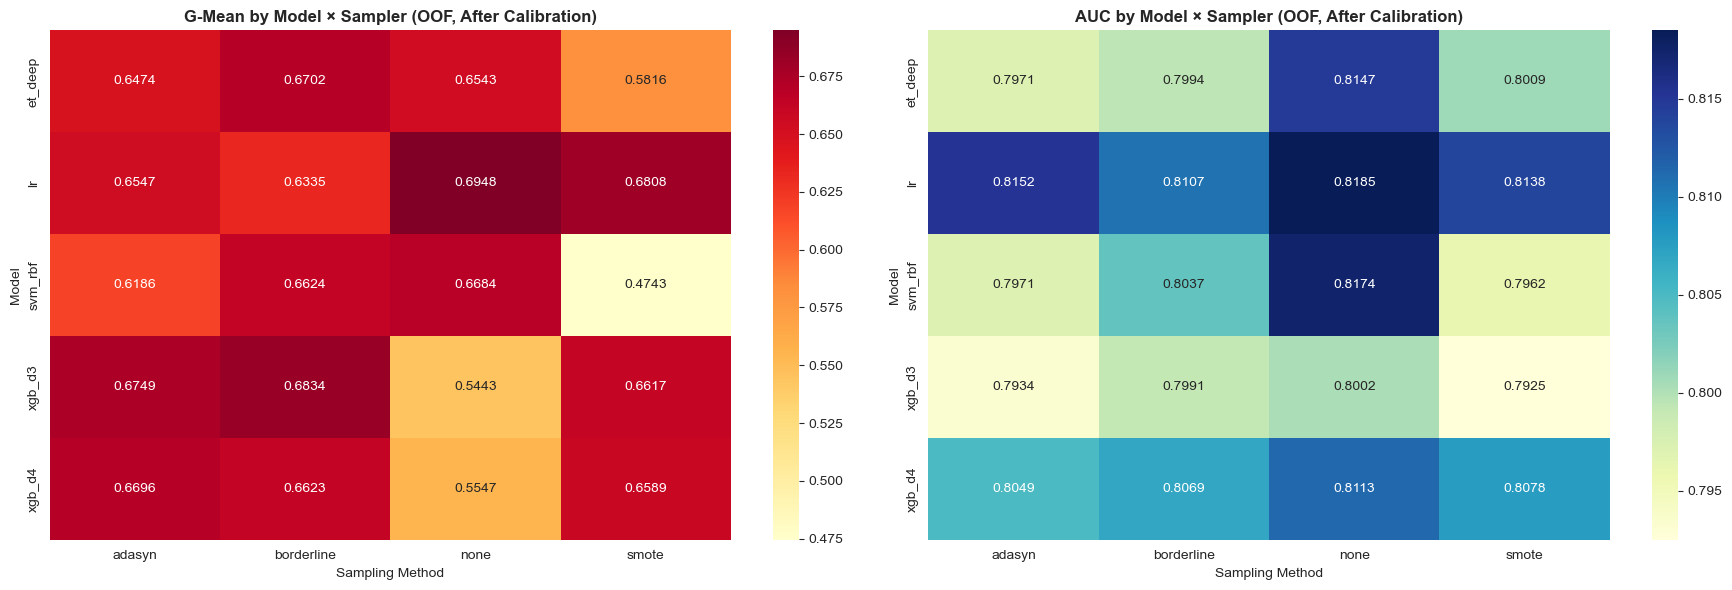

In [22]:
# ================================================
# 网格搜索热力图: 各模型×采样配置的 G-Mean
# ================================================

pivot_gmean = df_res.pivot(index="model", columns="sampler", values="gmean")
pivot_auc = df_res.pivot(index="model", columns="sampler", values="auc")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]

sns.heatmap(pivot_gmean, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax)
ax.set_title("G-Mean by Model × Sampler (OOF, After Calibration)", fontsize=12, fontweight="bold")
ax.set_xlabel("Sampling Method")
ax.set_ylabel("Model")

ax = axes[1]

sns.heatmap(pivot_auc, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax)
ax.set_title("AUC by Model × Sampler (OOF, After Calibration)", fontsize=12, fontweight="bold")
ax.set_xlabel("Sampling Method")
ax.set_ylabel("Model")

plt.tight_layout()
plt.savefig("Image/viz_v8_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


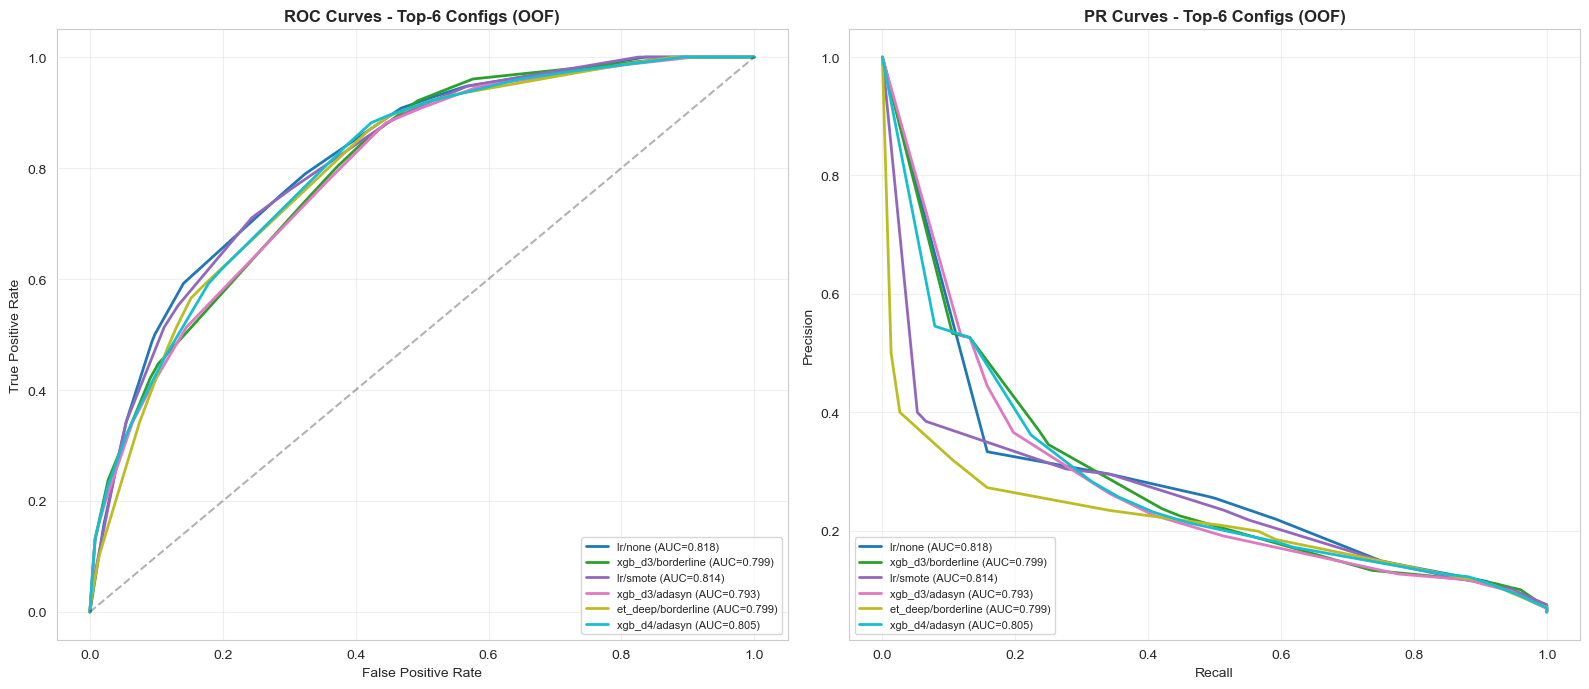

In [23]:
# ================================================
# ROC & PR 曲线: Top-6 配置
# ================================================
top6_df = df_res.head(6).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 6))

for i, row in top6_df.iterrows():
    label = f"{row['model']}/{row['sampler']} (AUC={row['auc']:.3f})"
    
    # ROC
    fpr_t, tpr_t, _ = roc_curve(y_train, row["oof_cal_oof"])
    axes[0].plot(fpr_t, tpr_t, color=colors[i], linestyle="-", linewidth=2, label=label)

    # PR
    prec_t, rec_t, _ = precision_recall_curve(y_train, row["oof_cal_oof"])
    axes[1].plot(rec_t, prec_t, color=colors[i], linestyle="-", linewidth=2, label=label)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves - Top-6 Configs (OOF)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves - Top-6 Configs (OOF)", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=8, loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Image/viz_v8_roc_pr_top6.png", dpi=150, bbox_inches="tight")
plt.show()


---

## 阶段 6: Stacking 集成 vs 简单平均

### 两种集成策略对比

| 策略 | 说明 |
|------|------|
| **简单平均** | top-12 配置的概率直接取算术平均 |
| **Stacking (L1-LR)** | L1 正则化 Logistic Regression 学习各配置权重 |

最终选择 **G-Mean 更高** 的策略.

---

In [24]:
print("\n" + "=" * 70)
print("[集成] Stacking (L1-LR 元分类器) vs 简单平均")
print("=" * 70)

# 取 Top-12 配置做元特征
top_keys = [(r.model, r.sampler) for r in df_res.head(12).itertuples(index=False)]

meta_X_train_list = []
meta_X_test_list = []

for k in top_keys:
    row = df_res[(df_res["model"] == k[0]) & (df_res["sampler"] == k[1])].iloc[0]
    meta_X_train_list.append(row["oof_cal_oof"])
    meta_X_test_list.append(row["oof_cal_test"])

# 构造元特征矩阵 (N × 12)
meta_X_train = np.column_stack(meta_X_train_list)
meta_X_test = np.column_stack(meta_X_test_list)
print(f"  元特征: {len(top_keys)} 个配置 → 形状 {meta_X_train.shape}")

# Stacking: L1-LR 元分类器, 搜索最佳正则强度 C
best_meta = None
best_meta_score = -1

for C in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
    mc = LogisticRegression(
        C=C, class_weight="balanced", max_iter=5000,
        penalty="l1", solver="saga", random_state=42
    )
    mc.fit(meta_X_train, y_train)
    mop = mc.predict_proba(meta_X_train)[:, 1]

    # 元分类器输出再做一次 Isotonic 校准
    try:
        ir2 = IsotonicRegression(out_of_bounds="clip", y_min=0.001, y_max=0.999)
        ir2.fit(mop, y_train)
        mop_c = np.clip(ir2.transform(mop), 0.001, 0.999)
    
    except Exception:
        mop_c = mop
        ir2 = None

    b = search_threshold(y_train, mop_c, min_recall=0.90)
    if b["score"] > best_meta_score:
        best_meta_score = b["score"]
        best_meta = {
            "C": C, "clf": mc, "calibrator": ir2,
            "oof_proba": mop_c, "thr": b["thr"],
            "recall": b["recall"], "precision": b["precision"],
            "gmean": b["gmean"], "f1": b["f1"]
        }

# 简单平均集成 (baseline)
avg_oof = np.mean(meta_X_train_list, axis=0)
avg_test = np.mean(meta_X_test_list, axis=0)
avg_b = search_threshold(y_train, avg_oof, min_recall=0.90)

print(f"  Stacking (C={best_meta['C']}): "
      f"R={best_meta['recall']:.4f} P={best_meta['precision']:.4f} "
      f"G={best_meta['gmean']:.4f} F1={best_meta['f1']:.4f}")
print(f"  简单平均: "
      f"R={avg_b['recall']:.4f} P={avg_b['precision']:.4f} "
      f"G={avg_b['gmean']:.4f} F1={avg_b['f1']:.4f}")


# 自动选择: G-Mean 更高的策略
use_stack = best_meta["gmean"] >= avg_b["gmean"]
if use_stack:
    print("  → 选择 Stacking")
    final_oof = best_meta["oof_proba"]
    rtp = best_meta["clf"].predict_proba(meta_X_test)[:, 1]
    final_test = np.clip(best_meta["calibrator"].transform(rtp), 0.001, 0.999) if best_meta["calibrator"] else rtp
    final_thr = best_meta["thr"]
else:
    print("  → 选择 简单平均")
    final_oof = avg_oof
    final_test = avg_test
    final_thr = avg_b["thr"]

oof_pred = (final_oof >= final_thr).astype(int)

print(f"\n[最终 OOF] thr={final_thr:.4f}, "
      f"R={recall_score(y_train, oof_pred, pos_label=1, zero_division=0):.4f}, "
      f"P={precision_score(y_train, oof_pred, pos_label=1, zero_division=0):.4f}, "
      f"G={gmean(y_train, oof_pred):.4f}")



[集成] Stacking (L1-LR 元分类器) vs 简单平均
  元特征: 12 个配置 → 形状 (1212, 12)
  Stacking (C=0.1): R=0.9079 P=0.1364 G=0.7474 F1=0.2371
  简单平均: R=0.9079 P=0.1243 G=0.7208 F1=0.2187
  → 选择 Stacking

[最终 OOF] thr=0.0385, R=0.9079, P=0.1364, G=0.7474


---

## 阶段 7: 测试集最终评估

>  测试集**只被使用一次**. 所有模型选择 / 阈值 / 校准都只基于训练集 OOF 概率.

---

In [25]:
print("\n" + "=" * 70)
print("=== FINAL TEST SET ===")
print("=" * 70)

# 用在 OOF 上找到的最佳阈值 → 预测测试集
final_pred = (final_test >= final_thr).astype(int)

# 计算指标
rec = recall_score(y_test, final_pred, pos_label=1, zero_division=0)
prec = precision_score(y_test, final_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test, final_pred, pos_label=1, zero_division=0)
spec = recall_score(y_test, final_pred, pos_label=0, zero_division=0)
gm = float(np.sqrt(rec * spec))
auc_roc = roc_auc_score(y_test, final_test)
mcc = matthews_corrcoef(y_test, final_pred)
bacc = balanced_accuracy_score(y_test, final_pred)
cm = confusion_matrix(y_test, final_pred)
brier = brier_score_loss(y_test, final_test)
prec_c, rec_c, _ = precision_recall_curve(y_test, final_test)
pr_auc = auc(rec_c, prec_c)

# 打印报告
print(classification_report(y_test, final_pred, target_names=["Pass (0)", "Fail (1)"]))
print(f"\n混淆矩阵: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")
print(f"\n核心指标:")
print(f"  G-Mean       = {gm:.4f}")
print(f"  AUC-ROC      = {auc_roc:.4f}")
print(f"  AUC-PR       = {pr_auc:.4f}")
print(f"  Recall       = {rec:.4f}")
print(f"  Precision    = {prec:.4f}")
print(f"  F1-Score     = {f1:.4f}")
print(f"  Specificity  = {spec:.4f}")
print(f"  MCC          = {mcc:.4f}")
print(f"  Balanced Acc = {bacc:.4f}")
print(f"  Brier Loss   = {brier:.4f}")


=== FINAL TEST SET ===
              precision    recall  f1-score   support

    Pass (0)       0.99      0.58      0.74       284
    Fail (1)       0.13      0.95      0.23        19

    accuracy                           0.61       303
   macro avg       0.56      0.77      0.48       303
weighted avg       0.94      0.61      0.70       303


混淆矩阵: TN=166 FP=118 FN=1 TP=18

核心指标:
  G-Mean       = 0.7441
  AUC-ROC      = 0.8439
  AUC-PR       = 0.2536
  Recall       = 0.9474
  Precision    = 0.1324
  F1-Score     = 0.2323
  Specificity  = 0.5845
  MCC          = 0.2592
  Balanced Acc = 0.7659
  Brier Loss   = 0.0601


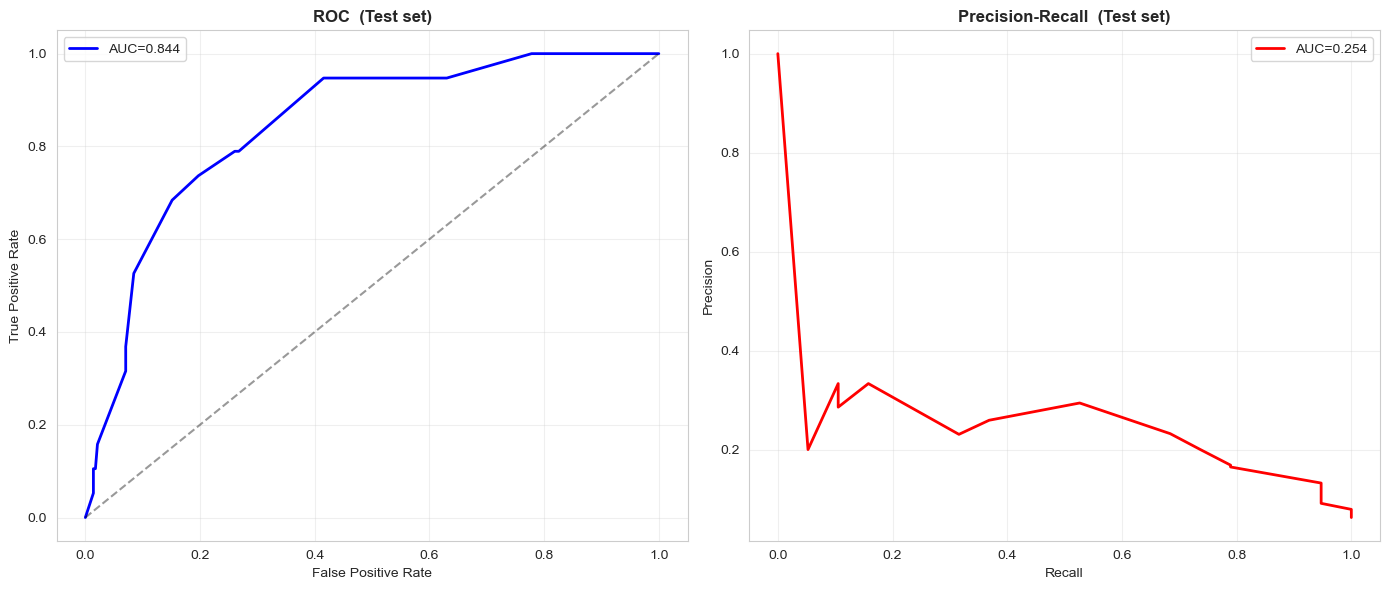

In [26]:
# ================================================
# 测试集最终结果可视化
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fpr, tpr, _ = roc_curve(y_test, final_test)

axes[0].plot(fpr, tpr, "b-", lw=2, label=f"AUC={auc_roc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC  (Test set)", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rec_c, prec_c, "r-", lw=2, label=f"AUC={pr_auc:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall  (Test set)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Image/secom_v8_final.png", dpi=150, bbox_inches="tight")
plt.show()

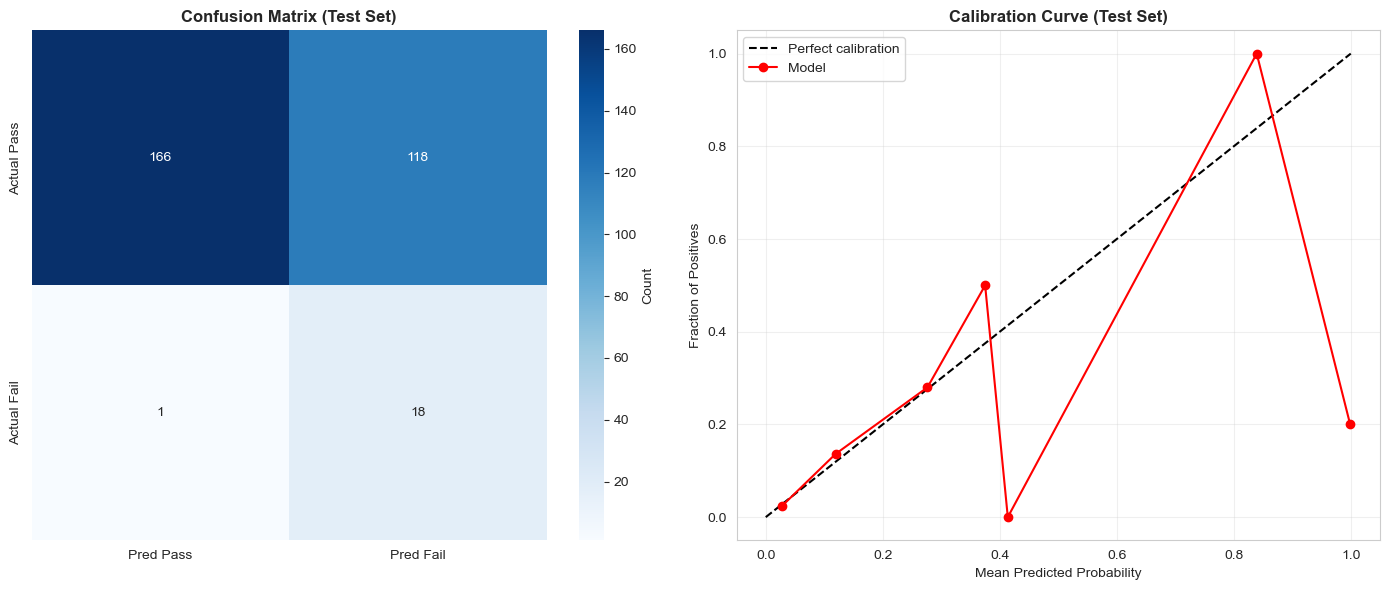

In [27]:
# ================================================
# 混淆矩阵 & 校准曲线
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 混淆矩阵热力图
ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Pass", "Pred Fail"],
            yticklabels=["Actual Pass", "Actual Fail"],
            ax=ax, cbar_kws={"label": "Count"})
ax.set_title("Confusion Matrix (Test Set)", fontsize=12, fontweight="bold")

# 校准曲线
ax = axes[1]
try:
    frac_pos, mean_pred = calibration_curve(y_test, final_test, n_bins=10)
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "ro-", label="Model")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title("Calibration Curve (Test Set)", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

except Exception as e:
    ax.text(0.5, 0.5, f"Calibration curve not available\n({str(e)[:50]})",
            ha="center", va="center")
    ax.set_title("Calibration Curve")

plt.tight_layout()
plt.savefig("Image/viz_v8_confusion_calibration.png", dpi=150, bbox_inches="tight")
plt.show()


---

## 阶段 8: SHAP 可解释性分析

---

### 8.1 SHAP 可解释性分析

In [28]:
# ================================================
# SHAP: 训练最佳 XGBoost 模型进行解释
# ================================================

# 找到最佳基于树的配置 (XGB/LGB/RF/ET) 用于 SHAP 分析
tree_models = ["xgb_d3", "xgb_d4", "lgb_d3", "rf_shallow", "et_deep"]
df_tree_res = df_res[df_res["model"].isin(tree_models)].reset_index(drop=True)
best_tree = df_tree_res.iloc[0]
print(f"\n[SHAP] 使用最佳树模型: {best_tree['model']} / {best_tree['sampler']}")

# 用完整训练集 + 最佳配置的采样重新训练
shap_sampler = make_sampler(best_tree["sampler"], 42)
if shap_sampler is not None:
    try:
        Xtr_shap, ytr_shap = shap_sampler.fit_resample(X_train, y_train)

    except Exception:
        Xtr_shap, ytr_shap = X_train, y_train

else:
    Xtr_shap, ytr_shap = X_train, y_train

shap_model = make_model(best_tree["model"], 42, pos_weight)
shap_model.fit(Xtr_shap, ytr_shap)

print(f"[SHAP] 模型训练完成")


[SHAP] 使用最佳树模型: xgb_d3 / borderline
[SHAP] 模型训练完成


[SHAP] values shape: (303, 120)


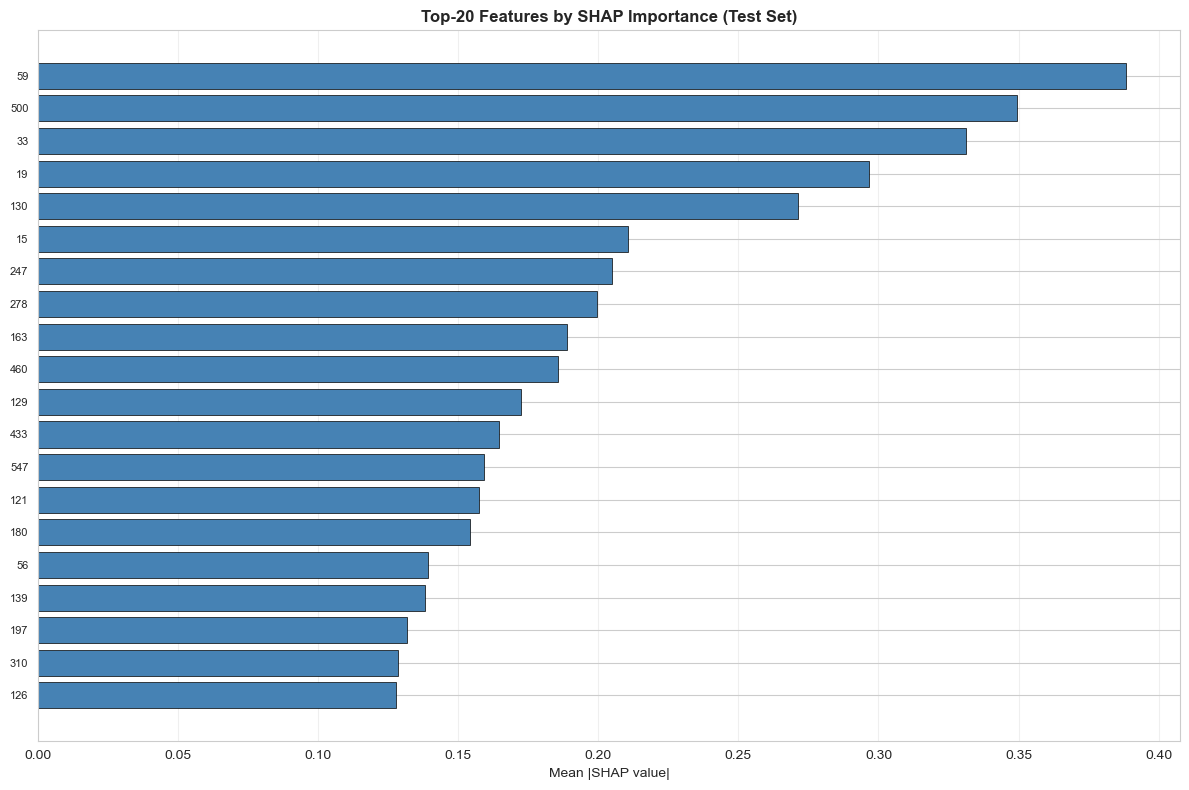

[SHAP] Top-20 主导失效特征:
  F    59: SHAP=0.3882
  F   500: SHAP=0.3495
  F    33: SHAP=0.3312
  F    19: SHAP=0.2964
  F   130: SHAP=0.2714
  F    15: SHAP=0.2105
  F   247: SHAP=0.2047
  F   278: SHAP=0.1994
  F   163: SHAP=0.1889
  F   460: SHAP=0.1857
  F   129: SHAP=0.1725
  F   433: SHAP=0.1646
  F   547: SHAP=0.1591
  F   121: SHAP=0.1575
  F   180: SHAP=0.1543
  F    56: SHAP=0.1393
  F   139: SHAP=0.1382
  F   197: SHAP=0.1317
  F   310: SHAP=0.1286
  F   126: SHAP=0.1278


In [29]:
# ================================================
# SHAP: 全局特征重要性 (Top-20)
# ================================================
explainer = shap.TreeExplainer(shap_model)
shap_raw = explainer.shap_values(X_test)

# 处理 SHAP 输出格式差异:
#   旧版: list of [neg_shap, pos_shap] (每个 2D)
#   新版: 3D array (n_samples, n_features, n_classes)
if isinstance(shap_raw, list):
    shap_vals_arr = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
elif hasattr(shap_raw, 'ndim') and shap_raw.ndim == 3:
    # (n_samples, n_features, n_classes) -> 取正类
    shap_vals_arr = shap_raw[:, :, min(1, shap_raw.shape[2] - 1)]
else:
    shap_vals_arr = np.asarray(shap_raw)
shap_vals_arr = np.atleast_2d(shap_vals_arr)
print(f"[SHAP] values shape: {shap_vals_arr.shape}")

shap_imp = np.mean(np.abs(shap_vals_arr), axis=0)
shap_imp = np.asarray(shap_imp).reshape(-1)

shap_imp_df = pd.DataFrame({
    "feature": [str(selected_feats[i]) for i in range(len(selected_feats))],
    "shap_importance": shap_imp.tolist()
}).sort_values("shap_importance", ascending=False)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
top20_shap = shap_imp_df.head(20)
bars = ax.barh(range(len(top20_shap)), top20_shap["shap_importance"].values[::-1],
               color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(top20_shap)))
ax.set_yticklabels(top20_shap["feature"].values[::-1], fontsize=8)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top-20 Features by SHAP Importance (Test Set)", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("Image/viz_v8_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"[SHAP] Top-20 主导失效特征:")
for _, row in shap_imp_df.head(20).iterrows():
    print(f"  F{row['feature']:>6}: SHAP={row['shap_importance']:.4f}")


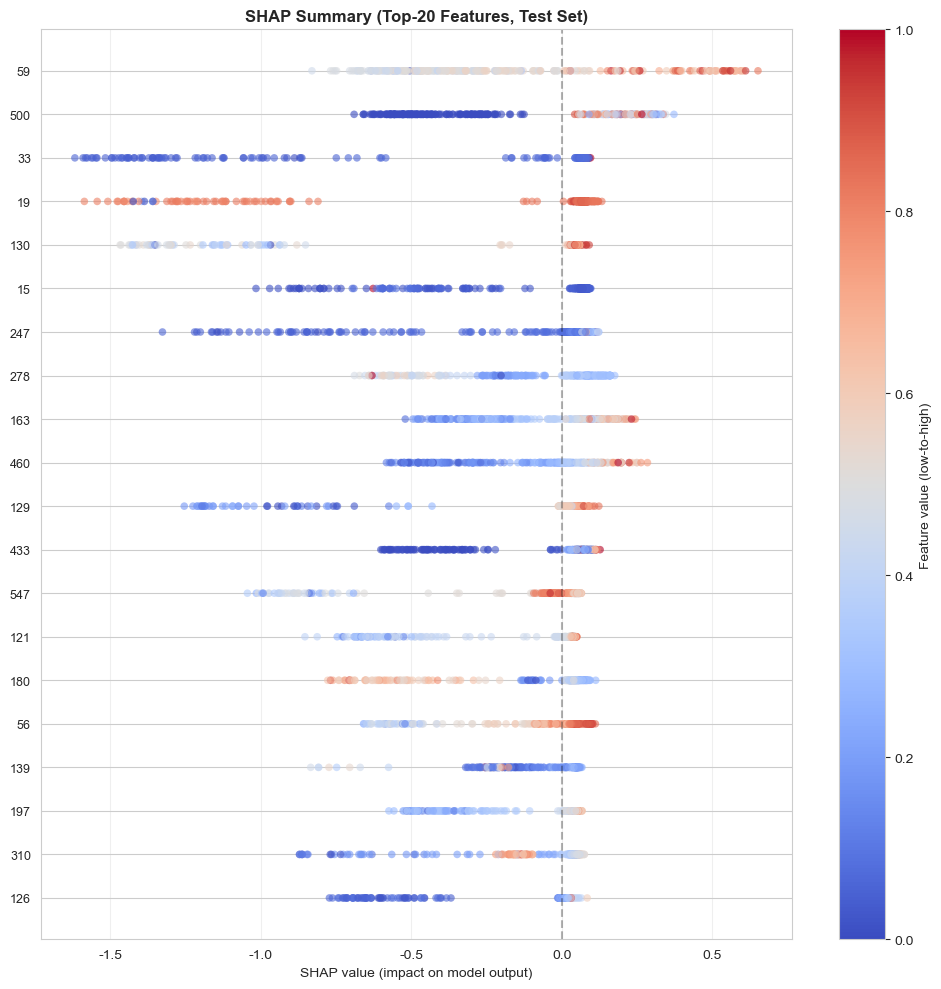

In [30]:
# ================================================
# SHAP: Summary Beeswarm 图 (Top-20)
# ================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sorted_idx = np.argsort(shap_imp)[::-1][:20]
feature_labels = [str(selected_feats[i]) for i in sorted_idx]

for pos, feat_idx in enumerate(sorted_idx[::-1]):
    sv = np.asarray(shap_vals_arr[:, feat_idx]).reshape(-1)
    fv = np.asarray(X_test[:, feat_idx]).reshape(-1)
    fv_norm = (fv - fv.min()) / max(1e-8, fv.max() - fv.min())
    ax.scatter(sv, [pos] * len(sv), c=fv_norm, cmap="coolwarm",
               alpha=0.6, s=30, edgecolors="none")

ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels(feature_labels[::-1], fontsize=9)
ax.set_xlabel("SHAP value (impact on model output)")
ax.set_title("SHAP Summary (Top-20 Features, Test Set)", fontsize=12, fontweight="bold")
ax.axvline(x=0, color="black", linestyle="--", alpha=0.3)
ax.grid(axis="x", alpha=0.3)
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Feature value (low-to-high)")
plt.tight_layout()
plt.savefig("Image/viz_v8_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


---

### 8.3 传感器批次变异系数 (CV) 分析

**核心思路**: 传感器在不同批次间的变异系数（CV = std/|mean|）越高，说明该工艺参数越不稳定。高 CV + 高 SHAP 的传感器指向了最关键的工艺波动来源，是识别问题工艺腔室的重要信号。

- **X轴**: 传感器跨批次的平均 CV（%）
- **Y轴**: 传感器的 SHAP 重要性
- **红色虚线**: CV=40% 阈值线（可调整阈值）
- **蓝色虚线**: SHAP 中位数阈值线
- **右上角红色星号**: 既高 CV 又高 SHAP 的传感器 → **需要重点关注**


In [31]:
# ================================================
# 阶段 8.3: 传感器批次变异系数 (CV) 分析
# ================================================
# - CV 基于原始未插补数据（保留真实物理波动），但使用与模型训练相同的样本掩码（mask_clean）
# - 仅对 SHAP 选中的重要传感器计算 CV，确保 CV 与 SHAP 可对齐
# - 在 Step 4 中一次性保存批次 CV 列表，避免后续绘图重复计算

# ----------------------------
# Step 1: 加载原始数据与标签
# ----------------------------
# 若前面阶段已加载，可注释掉此部分；此处为保证阶段独立性重新加载
df_raw_orig = pd.read_csv("Data/secom.data", sep=" ", header=None)
labels_ts = pd.read_csv("Data/secom_labels.data", sep=" ", header=None)
labels_ts.columns = ["label", "timestamp"]
labels_ts["timestamp"] = labels_ts["timestamp"].str.strip('"')
labels_ts["ts"] = pd.to_datetime(labels_ts["timestamp"],
                                  format="%d/%m/%Y %H:%M:%S", dayfirst=True)
labels_ts["date"] = labels_ts["ts"].dt.date
labels_ts["batch"] = labels_ts["date"]  # 按日期划分批次
labels_ts["label"] = labels_ts["label"].map({-1: 0, 1: 1})  # 0=良品, 1=不良
y_orig = labels_ts["label"].values.astype(int)
batches = labels_ts["batch"].unique()
n_batches = len(batches)
print(f"[CV] 原始样本: {df_raw_orig.shape[0]}, 批次数量: {n_batches}")

# ----------------------------
# Step 2: 缺失率过滤（与清洗流程一致）
# ----------------------------
missing_rates = df_raw_orig.isnull().mean()
keep_cols_orig = df_raw_orig.columns[missing_rates <= 0.70].tolist()
df_filt = df_raw_orig[keep_cols_orig].copy()

# ----------------------------
# Step 3: 生成清洗样本掩码 mask_clean（基于 KNN 插补 + z-score）
# ----------------------------
imp_knn = KNNImputer(n_neighbors=5, weights="distance")
df_imp_cv = pd.DataFrame(imp_knn.fit_transform(df_filt), columns=df_filt.columns)
z_cv = np.abs(stats.zscore(df_imp_cv.values, axis=0))
mask_clean = (z_cv > 5).sum(axis=1) <= 8
print(f"[CV] 清洗后保留样本数: {mask_clean.sum()} (正例={(y_orig[mask_clean] == 1).sum()})")

# ----------------------------
# Step 4: 基于原始数据 + mask_clean + selected_feats 计算 CV
# ----------------------------
df_cv = df_raw_orig.loc[mask_clean, keep_cols_orig].copy()
batch_cv = labels_ts.loc[mask_clean, "batch"].values

# 仅对 SHAP 选中的特征计算 CV（selected_feats 已在前面阶段定义）
N_TOP = 20
shap_rank_df = pd.DataFrame({
    "feat_str": [str(f) for f in selected_feats],
    "feat_int": [int(f) for f in selected_feats],
    "shap": shap_imp
}).sort_values("shap", ascending=False).head(N_TOP)

selected_indices = shap_rank_df["feat_int"].tolist()
cv_cols = [c for c in keep_cols_orig if int(c) in selected_indices]
print(f"[CV] 将在 Top-{N_TOP} SHAP 传感器上计算 CV，共 {len(cv_cols)} 个")

def safe_cv(vals):
    """计算一组值的 CV，忽略缺失，样本数不足或均值接近0时返回 NaN"""
    vals = vals.dropna()
    if len(vals) < 2 or abs(vals.mean()) < 1e-6:
        return np.nan
    return vals.std() / abs(vals.mean())

# 一次性保存每个传感器的批次 CV 列表和平均 CV
batch_cv_dict = {}   # {feature_idx: [cv_batch1, cv_batch2, ...]}
cv_per_sensor = {}

for col in cv_cols:
    sensor_vals = df_cv[col]
    batch_cvs = []
    for b in batches:
        vals = sensor_vals[batch_cv == b]
        batch_cvs.append(safe_cv(vals))
        
    # 保存原始列表（含NaN，绘图时再清洗）
    batch_cv_dict[int(col)] = batch_cvs
    
    # 计算跨批次平均 CV（忽略 NaN）
    valid = [c for c in batch_cvs if not np.isnan(c)]
    if valid:
        cv_per_sensor[col] = np.mean(valid)

# 构建 cv_df 数据框
cv_df = pd.DataFrame([
    {"feature": f"F{int(k)}", "feature_idx": int(k),
     "cv": v, "cv_pct": v * 100}
    for k, v in cv_per_sensor.items()
])
cv_df = cv_df.sort_values("cv", ascending=False).reset_index(drop=True)

print(f"[CV] 有效传感器数: {len(cv_df)}")
print(f"[CV] CV 统计: min={cv_df['cv_pct'].min():.1f}%, "
      f"max={cv_df['cv_pct'].max():.1f}%, "
      f"mean={cv_df['cv_pct'].mean():.1f}%, "
      f"median={cv_df['cv_pct'].median():.1f}%")
print(f"[CV] CV > 40%: {(cv_df['cv'] > 0.40).sum()} 个传感器")
print(f"[CV] CV > 100%: {(cv_df['cv'] > 1.00).sum()} 个传感器")

# ----------------------------
# Step 5: 获取 SHAP 重要性（已在前面阶段定义 shap_imp 和 selected_feats）
# ----------------------------
test_fail_prob = final_test  # 来自阶段6
if 'final_test' in dir():
    print(f"[CV] 测试样本失效概率: min={test_fail_prob.min():.4f}, "
          f"max={test_fail_prob.max():.4f}, mean={test_fail_prob.mean():.4f}")

shap_imp_vec = shap_imp   # 来自阶段8.2
shap_df = pd.DataFrame({
    "feature": [str(selected_feats[i]) for i in range(len(selected_feats))],
    "feature_idx": [int(selected_feats[i]) for i in range(len(selected_feats))],
    "shap": shap_imp_vec
})

# ----------------------------
# Step 6: 合并 CV 与 SHAP
# ----------------------------
merged = shap_df.merge(cv_df[["feature_idx", "cv", "cv_pct"]],
                       on="feature_idx", how="inner")
merged = merged.sort_values("shap", ascending=False).reset_index(drop=True)

print(f"\n[CV+SHAP] 合并后传感器数: {len(merged)}")
print(f"[CV+SHAP] Top-15 高 SHAP 传感器的 CV:")
for _, row in merged.head(15).iterrows():
    print(f"  {row['feature']:>8}: SHAP={row['shap']:.4f}, CV={row['cv_pct']:.1f}%")

[CV] 原始样本: 1567, 批次数量: 86
[CV] 清洗后保留样本数: 1515 (正例=95)
[CV] 将在 Top-20 SHAP 传感器上计算 CV，共 20 个
[CV] 有效传感器数: 20
[CV] CV 统计: min=0.4%, max=520.3%, mean=66.7%, median=15.7%
[CV] CV > 40%: 7 个传感器
[CV] CV > 100%: 4 个传感器
[CV] 测试样本失效概率: min=0.0010, max=0.9990, mean=0.0773

[CV+SHAP] 合并后传感器数: 20
[CV+SHAP] Top-15 高 SHAP 传感器的 CV:
        59: SHAP=0.3882, CV=520.3%
       500: SHAP=0.3495, CV=150.4%
        33: SHAP=0.3312, CV=7.8%
        19: SHAP=0.2964, CV=1.0%
       130: SHAP=0.2714, CV=6.7%
        15: SHAP=0.2105, CV=2.3%
       247: SHAP=0.2047, CV=74.7%
       278: SHAP=0.1994, CV=27.9%
       163: SHAP=0.1889, CV=43.4%
       460: SHAP=0.1857, CV=38.8%
       129: SHAP=0.1725, CV=255.9%
       433: SHAP=0.1646, CV=109.0%
       547: SHAP=0.1591, CV=1.1%
       121: SHAP=0.1575, CV=0.4%
       180: SHAP=0.1543, CV=14.4%


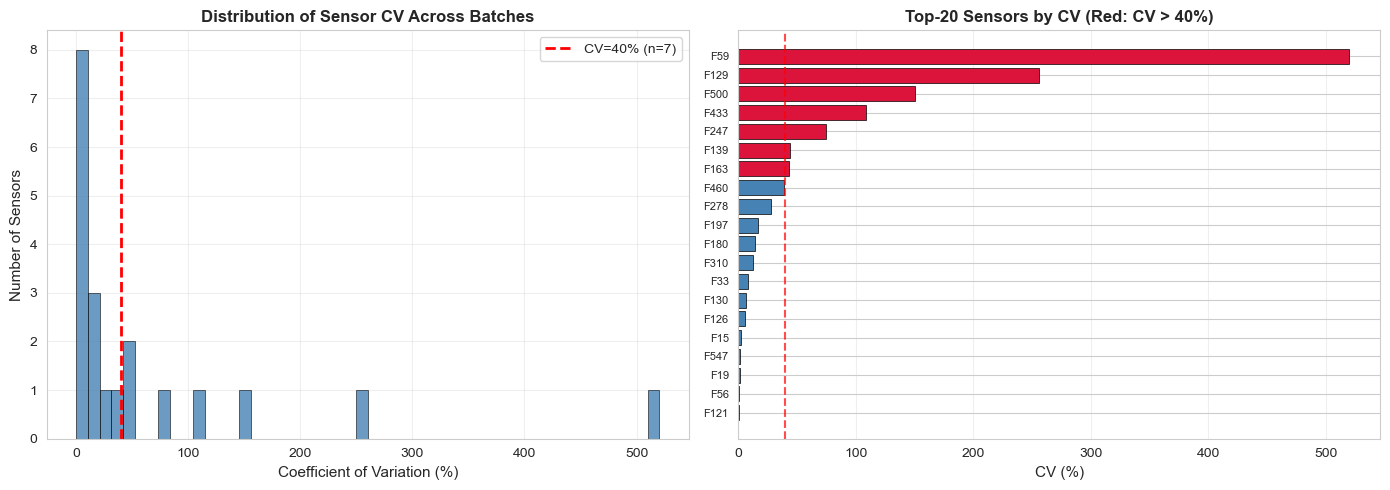

[CV] viz_v8_cv_distribution.png 已保存


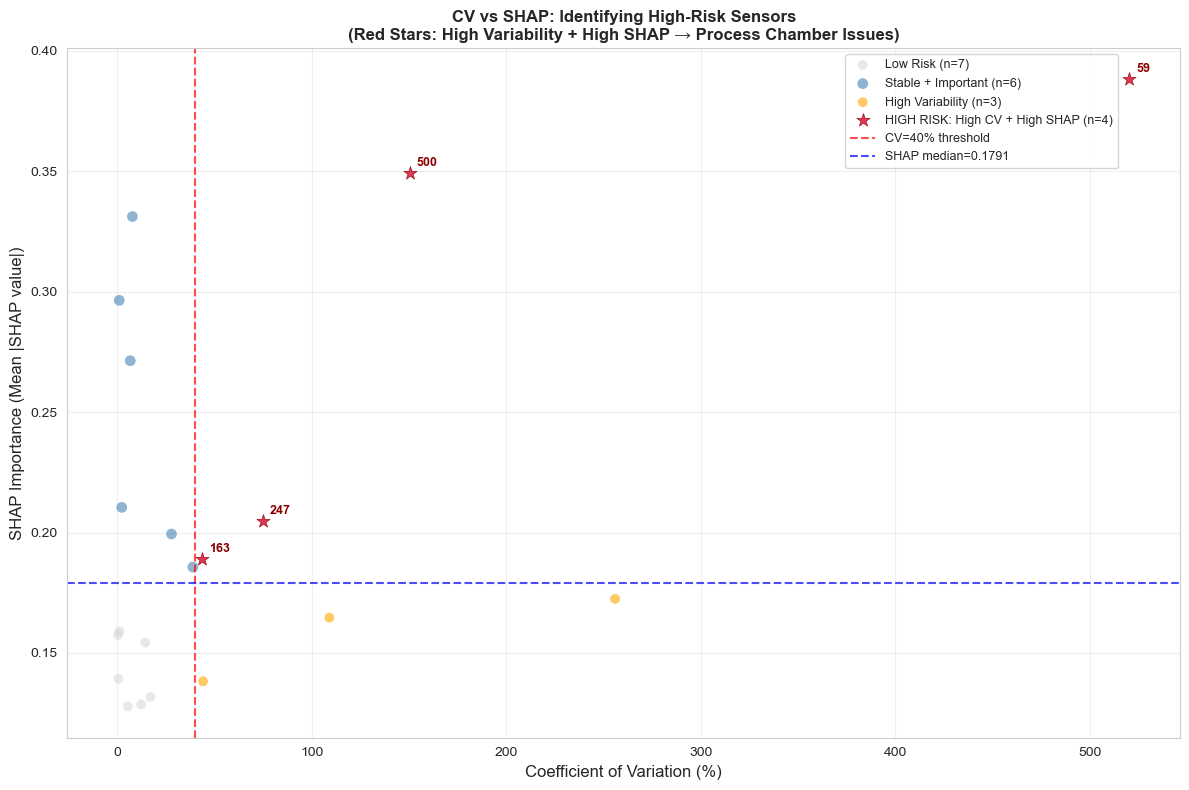

[CV] viz_v8_cv_shap_scatter.png 已保存


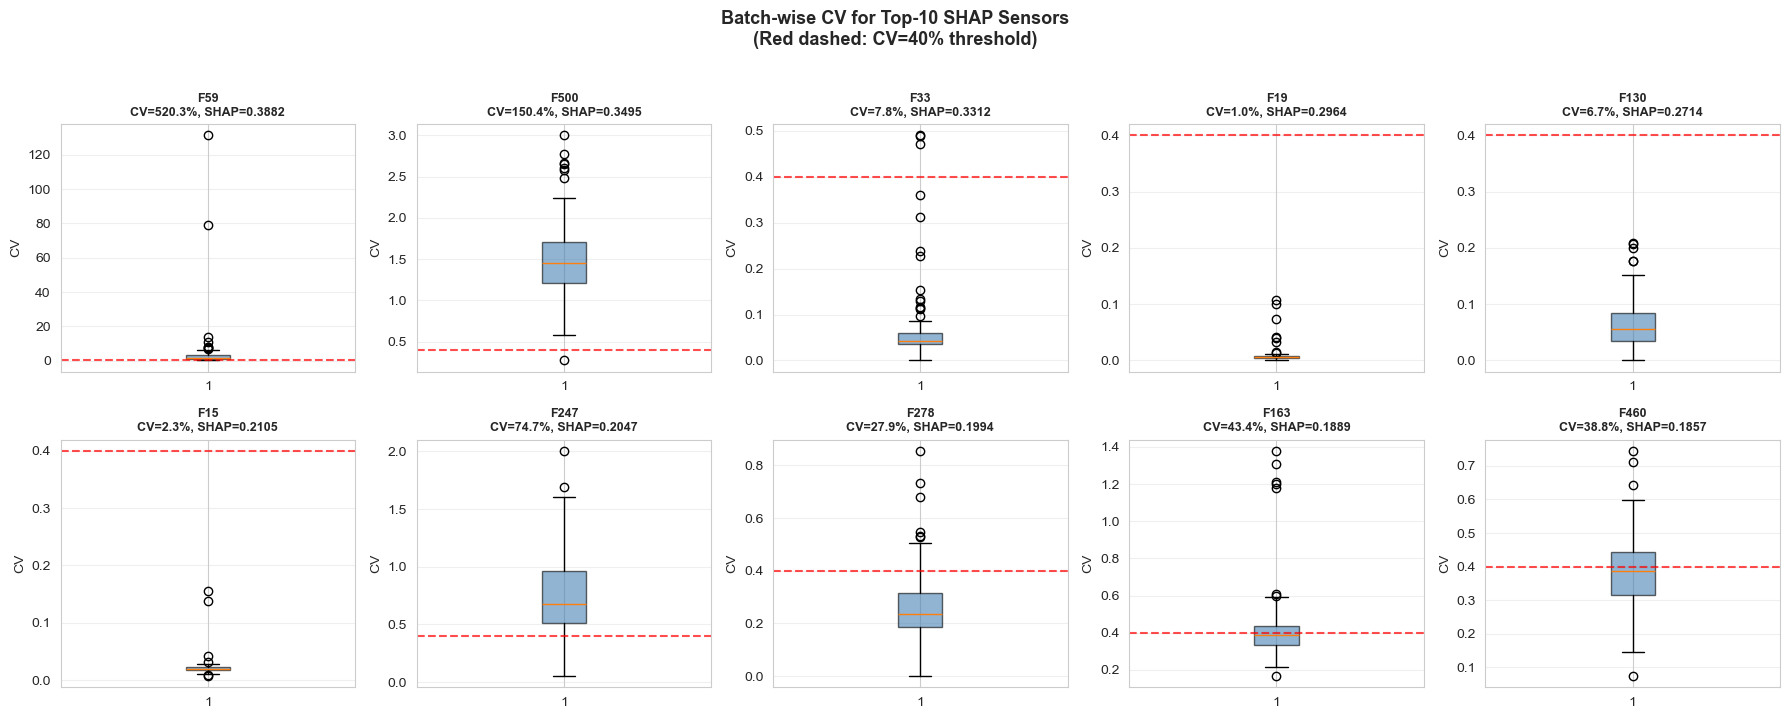

[CV] viz_v8_cv_batch_boxplot.png 已保存


In [32]:
# ================================================
# 可视化 1: CV 分布直方图
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(cv_df["cv_pct"], bins=50, color="steelblue",
         edgecolor="black", linewidth=0.5, alpha=0.8)
ax1.axvline(x=40, color="red", linestyle="--", linewidth=2,
            label=f"CV=40% (n={(cv_df['cv'] > 0.40).sum()})")
ax1.set_xlabel("Coefficient of Variation (%)", fontsize=11)
ax1.set_ylabel("Number of Sensors", fontsize=11)
ax1.set_title("Distribution of Sensor CV Across Batches",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2 = axes[1]
top20_cv = cv_df.head(20)
colors = ["crimson" if cv > 40 else "steelblue" for cv in top20_cv["cv_pct"]]
bars = ax2.barh(range(len(top20_cv)), top20_cv["cv_pct"].values[::-1],
               color=colors[::-1], edgecolor="black", linewidth=0.5)
ax2.axvline(x=40, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
ax2.set_yticks(range(len(top20_cv)))
ax2.set_yticklabels([str(f) for f in top20_cv["feature"].values[::-1]], fontsize=8)
ax2.set_xlabel("CV (%)", fontsize=11)
ax2.set_title("Top-20 Sensors by CV (Red: CV > 40%)",
              fontsize=12, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("Image/viz_v8_cv_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("[CV] viz_v8_cv_distribution.png 已保存")

# ================================================
# 可视化 2: CV vs SHAP 散点图（识别高风险传感器）
# ================================================
fig, ax = plt.subplots(figsize=(12, 8))

# 计算阈值
cv_threshold = 0.40  # 40% (可调整)
shap_threshold = np.median(merged["shap"])

# 四个象限分类
q1 = merged[(merged["cv"] <= cv_threshold) & (merged["shap"] >= shap_threshold)]
q2 = merged[(merged["cv"] > cv_threshold) & (merged["shap"] >= shap_threshold)]
q3 = merged[(merged["cv"] <= cv_threshold) & (merged["shap"] < shap_threshold)]
q4 = merged[(merged["cv"] > cv_threshold) & (merged["shap"] < shap_threshold)]

# 绘制四个象限（按风险从低到高）
ax.scatter(q3["cv_pct"], q3["shap"], c="lightgray", s=50, alpha=0.5,
           label=f"Low Risk (n={len(q3)})", edgecolors="none")
ax.scatter(q1["cv_pct"], q1["shap"], c="steelblue", s=60, alpha=0.6,
           label=f"Stable + Important (n={len(q1)})", edgecolors="none")
ax.scatter(q4["cv_pct"], q4["shap"], c="orange", s=50, alpha=0.6,
           label=f"High Variability (n={len(q4)})", edgecolors="none")
ax.scatter(q2["cv_pct"], q2["shap"], c="crimson", s=100, alpha=0.85,
           marker="*", label=f"HIGH RISK: High CV + High SHAP (n={len(q2)})",
           edgecolors="darkred", linewidths=0.5)

# 标注高风险传感器
for _, row in q2.iterrows():
    ax.annotate(f"{row['feature']}",
                 (row["cv_pct"], row["shap"]),
                 fontsize=9, fontweight="bold",
                 xytext=(5, 5), textcoords="offset points",
                 color="darkred")

# 阈值线
ax.axvline(x=cv_threshold * 100, color="red", linestyle="--", linewidth=1.5,
           alpha=0.7, label=f"CV={cv_threshold*100:.0f}% threshold")
ax.axhline(y=shap_threshold, color="blue", linestyle="--", linewidth=1.5,
           alpha=0.7, label=f"SHAP median={shap_threshold:.4f}")

ax.set_xlabel("Coefficient of Variation (%)", fontsize=12)
ax.set_ylabel("SHAP Importance (Mean |SHAP value|)", fontsize=12)
ax.set_title("CV vs SHAP: Identifying High-Risk Sensors\n"
             "(Red Stars: High Variability + High SHAP → Process Chamber Issues)",
             fontsize=12, fontweight="bold")
#ax.legend(fontsize=9, loc="upper right")#挡住59的图标了
ax.legend(fontsize=9, loc="upper right", bbox_to_anchor=(0.95, 1))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Image/viz_v8_cv_shap_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[CV] viz_v8_cv_shap_scatter.png 已保存")

# ================================================
# 可视化 3: 高 SHAP 传感器的批次 CV 箱线图
# ================================================
top_shap_feats = merged.head(10)["feature_idx"].values
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat_idx in enumerate(top_shap_feats):
    ax = axes[i]
    feat_col = int(feat_idx)
    feat_name = f"F{feat_col}"

    # 计算每个批次的 CV
    batch_cv_vals = {}
    for batch in batches:
        batch_mask = batch_cv == batch
        vals = df_cv.iloc[batch_mask][feat_col].dropna()
        if len(vals) >= 2 and abs(vals.mean()) > 1e-6:
            batch_cv_vals[batch] = vals.std() / abs(vals.mean())

    cv_vals = list(batch_cv_vals.values())
    feat_cv = cv_df[cv_df["feature_idx"] == feat_col]["cv_pct"].values
    feat_cv_str = f"{feat_cv[0]:.1f}%" if len(feat_cv) > 0 else "N/A"
    feat_shap = merged[merged["feature_idx"] == feat_col]["shap"].values
    feat_shap_str = f"{feat_shap[0]:.4f}" if len(feat_shap) > 0 else "N/A"

    ax.boxplot(cv_vals, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
    ax.axhline(y=0.40, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.set_title(f"{feat_name}\nCV={feat_cv_str}, SHAP={feat_shap_str}",
                 fontsize=9, fontweight="bold")
    ax.set_ylabel("CV")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Batch-wise CV for Top-10 SHAP Sensors\n(Red dashed: CV=40% threshold)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("Image/viz_v8_cv_batch_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("[CV] viz_v8_cv_batch_boxplot.png 已保存")


In [33]:
# ================================================
# 关键发现汇总
# ================================================
print("\n" + "=" * 70)
print("[CV Analysis] 关键发现汇总")
print("=" * 70)

# 高风险传感器: SHAP 高 + CV > 40%
high_risk = merged[(merged["cv"] > 0.40) & (merged["shap"] >= shap_threshold)]
high_risk = high_risk.sort_values("shap", ascending=False)

print(f"\n【高风险传感器】(SHAP >= {shap_threshold:.4f} 且 CV > 40%):")
print(f"  数量: {len(high_risk)} 个")
if len(high_risk) > 0:
    print(f"\n  {'特征':<10} {'CV (%)':<12} {'SHAP':<12} {'风险描述'}")
    print(f"  {'-'*60}")
    for _, row in high_risk.iterrows():
        desc = ""  # 简化描述
        print(f"  {str(row['feature']):<10} {row['cv_pct']:>10.1f}% {row['shap']:>12.4f}  ⬆ 高变异 + 主导失效")

print(f"\n【工艺改进建议】")
if len(high_risk) > 0:
    for _, row in high_risk.iterrows():
        feat = row["feature"]
        cv_val = row["cv_pct"]
        print(f"  - {feat} (CV={cv_val:.1f}%): 建议对该传感器对应的工艺参数进行")
        print(f"    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。")

print(f"\n【象限分析统计】")
print(f"  高 CV + 高 SHAP (重点监控): {(merged['cv'] > 0.40).sum() & (merged['shap'] >= shap_threshold).sum() if len(merged) > 0 else 0} 个")
print(f"  低 CV + 高 SHAP (稳定关键): {((merged['cv'] <= 0.40) & (merged['shap'] >= shap_threshold)).sum()} 个")
print(f"  高 CV + 低 SHAP (批次波动): {((merged['cv'] > 0.40) & (merged['shap'] < shap_threshold)).sum()} 个")
print(f"  低 CV + 低 SHAP (正常传感器): {((merged['cv'] <= 0.40) & (merged['shap'] < shap_threshold)).sum()} 个")

# 关联分析: 失效样本的 CV 是否更高?
print(f"\n【失效关联分析】")
fail_probs_sorted = np.sort(test_fail_prob)[::-1]
high_prob_mask = test_fail_prob >= np.percentile(test_fail_prob, 75)
low_prob_mask = test_fail_prob <= np.percentile(test_fail_prob, 25)
print(f"  高失效概率样本 (top 25%): {high_prob_mask.sum()} 个")
print(f"  低失效概率样本 (bottom 25%): {low_prob_mask.sum()} 个")




[CV Analysis] 关键发现汇总

【高风险传感器】(SHAP >= 0.1791 且 CV > 40%):
  数量: 4 个

  特征         CV (%)       SHAP         风险描述
  ------------------------------------------------------------
  59              520.3%       0.3882  ⬆ 高变异 + 主导失效
  500             150.4%       0.3495  ⬆ 高变异 + 主导失效
  247              74.7%       0.2047  ⬆ 高变异 + 主导失效
  163              43.4%       0.1889  ⬆ 高变异 + 主导失效

【工艺改进建议】
  - 59 (CV=520.3%): 建议对该传感器对应的工艺参数进行
    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。
  - 500 (CV=150.4%): 建议对该传感器对应的工艺参数进行
    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。
  - 247 (CV=74.7%): 建议对该传感器对应的工艺参数进行
    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。
  - 163 (CV=43.4%): 建议对该传感器对应的工艺参数进行
    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。

【象限分析统计】
  高 CV + 高 SHAP (重点监控): 2 个
  低 CV + 高 SHAP (稳定关键): 6 个
  高 CV + 低 SHAP (批次波动): 3 个
  低 CV + 低 SHAP (正常传感器): 7 个

【失效关联分析】
  高失效概率样本 (top 25%): 89 个
  低失效概率样本 (bottom 25%): 106 个
